In [1]:
import pandas as pd
import numpy as np
import sys,os
sys.path.append("../")
from utils.utils import *
import matplotlib.pyplot as plt
import seaborn as sns
from src.fbsc import plot_signal_drift
from joblib import Parallel,delayed
from tqdm import tqdm 

In [2]:
D = pd.read_csv("../data/nph_data.csv").drop(columns=['position','mz','rt']).set_index("name").T
M = pd.read_csv("../data/nph_metadata.csv").set_index("sample_name")
M = M.sort_values(by=['batch','injection_order'])
M['injection_order'] = [x for x in range(1,len(M['injection_order'])+1)]
M['batch'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51])

# Plot QC Signal Against Injection Order

plotting only QC and Biological Samples


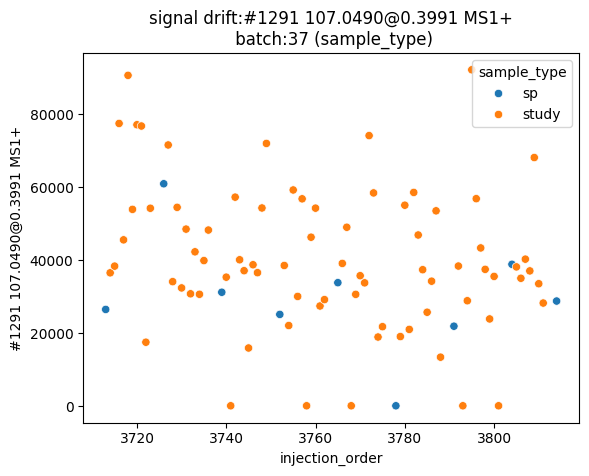

In [92]:
plot_signal_drift(data=D,metadata=M,include_all_samples=False,include_all_batches=False,random_state=10)

# Within Batch Effect Correction: QC-SVRC
* RBF function 
* QC signal intensity ~ injection_order (QC signal intensity as a function of injection order)

In [4]:
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler

In [ ]:
#Train on QC samples, apply corrections to Study Samples 
#Train on QC samples, apply corrections to Study Samples 
def svr_function(qc_intensity,bio_intensity,qc_injection_order,bio_injection_order):
    svr = SVR()
    svr.fit(qc_injection_order,qc_intensity)
    fitted_values = svr.predict(qc_injection_order)
    predicted_values = svr.predict(bio_injection_order)
    adjusted_qc = qc_intensity - fitted_values
    adjusted_bio = bio_intensity - predicted_values
    return pd.concat([adjusted_qc,adjusted_bio],axis=0)

def parallel_svr_correction(data,metadata,n_jobs=-1,qc='SP'):
    group_by_batch = data.groupby(metadata['batch'])
    lst = []
    for idx,batch in group_by_batch:
        QC = batch[batch.index.str.contains(f"{qc}")]
        Bio = batch[~batch.index.str.contains(f"{qc}")]
        qc_injection_order = metadata.loc[QC.index,'injection_order'].to_numpy().reshape(-1,1)
        bio_injection_order = metadata.loc[Bio.index,'injection_order'].to_numpy().reshape(-1,1)
        results = Parallel(n_jobs=n_jobs)(delayed(svr_function)(QC[col],Bio[col],qc_injection_order,bio_injection_order) for col in tqdm(QC.columns,desc=f'Correcting signals...'))
        results = pd.concat(results,axis=1)
        lst.append(results)
    return pd.concat(lst,axis=0)

In [94]:
results = parallel_svr_correction(D,M)

plotting only QC and Biological Samples


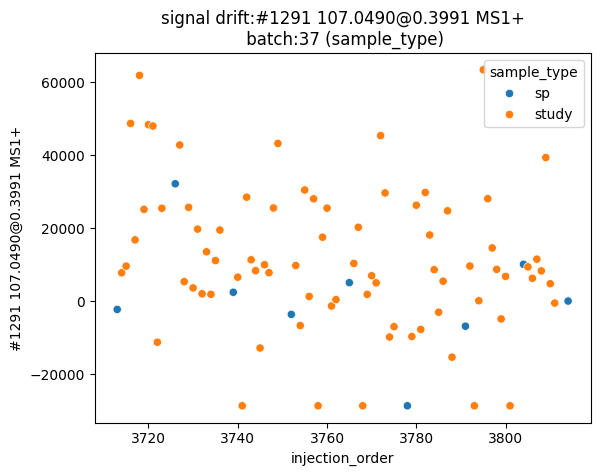

In [96]:
plot_signal_drift(data=results,metadata=M,include_all_samples=False,include_all_batches=False,random_state=10)

# Between Batch Effect Correction : Ratio-based Method 
- scales the intensity of each metabolic feature in each sample, using a factor defined as the ratio between the median intensity in QCs in corresponsing batch and the median intensity in QCs across batches

- group by batch and take the medians across QC samples 
- group by sample type and take the median across QC samples 

- scale each signal by this ratio 

In [ ]:
def ratio_based_correction(data,metadata,QC='sp'):
    D = data.copy()
    M = metadata.copy()
    QC = D.groupby(M['sample_type']).get_group(QC)
    median_across_qc = QC.median()
    median_qc_by_batch = []
    batches = M['batch'].unique()
    batch_group = QC.groupby(M['batch'])
    for batch in batches:
        median_qc_by_batch.append(batch_group.get_group(batch).median())
    scaling_factor = pd.concat(median_qc_by_batch,axis=1)
    scaling_factor.columns = M['batch'].unique()
    scaling_factor = scaling_factor.div(median_across_qc,axis=0)
    corrected_data = []
    batch_samples = D.groupby(M['batch'])
    for batch in batches:
        corrected_data.append(batch_samples.get_group(batch).mul(scaling_factor[batch],axis=1))
    corrected_data = pd.concat(corrected_data)
    corrected_data = corrected_data.loc[D.index]
    return corrected_data    
df = ratio_based_correction(D,M)